# VAE with Euclidean Latent Space

In [1]:
%pwd
%load_ext autoreload
%autoreload 2

### Imports

In [2]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders as dataloaders
import lib.models as models
import lib.trainer as trainer
import lib.utils as utils
import lib.models.utils.save_load_models as modelutils



### Set up and initialize data loader

In [3]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataloader

In [4]:
batch_size = 64

dataloader = dataloaders.load_fashion_mnist(batch_size)

### Model

In [5]:
data_dim = 784
latent_dim = 20
sftbeta = 1
device = "cpu"
encoder_width = 2
encoder_depth = 16
decoder_width = 1
decoder_depth = 16

model_config = { 'data_dim': data_dim, 'latent_dim': latent_dim, 'sftbeta': sftbeta, 'device': device, 'encoder_width': encoder_width, 'encoder_depth': encoder_depth, 'decoder_width': decoder_width, 'decoder_depth': decoder_depth}

euclidean_model = models.EuclideanVAE(model_config)
toroidal_model = models.ToroidalVAE(model_config)

### Optimizer

In [6]:
learning_rate = 0.001

euclidean_optimizer = optim.Adam(euclidean_model.parameters(), lr=learning_rate)
toroidal_optimizer = optim.Adam(toroidal_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [7]:
num_epochs = 2
log_interval = 100
device = "cpu"

trainer_config = {'num_epochs': num_epochs, 'log_interval': log_interval, 'device': device}

euclidean_history = trainer.MVAETrainer(euclidean_model, dataloader, euclidean_optimizer, trainer_config).train()
toroidal_history = trainer.MVAETrainer(toroidal_model, dataloader, toroidal_optimizer, trainer_config).train()

Trainer successfully initialized.
Training thegaussianVAE model.
Starting epoch 1/2
Epoch [1/2], Step [100/938], Loss: 151.1803
Epoch [1/2], Step [200/938], Loss: 73.7814
Epoch [1/2], Step [300/938], Loss: 36.8931
Epoch [1/2], Step [400/938], Loss: 18.0636
Epoch [1/2], Step [500/938], Loss: 8.5276
Epoch [1/2], Step [600/938], Loss: 3.8819
Epoch [1/2], Step [700/938], Loss: 1.7268
Epoch [1/2], Step [800/938], Loss: 0.7641
Epoch [1/2], Step [900/938], Loss: 0.3627
Starting epoch 1/2
Epoch [1/2], Step [100/938], Loss: 0.1708
Epoch [1/2], Step [200/938], Loss: 0.1120
Epoch [1/2], Step [300/938], Loss: 0.1083
Epoch [1/2], Step [400/938], Loss: 0.1027
Epoch [1/2], Step [500/938], Loss: 0.0814
Epoch [1/2], Step [600/938], Loss: 0.0921
Epoch [1/2], Step [700/938], Loss: 0.0853
Epoch [1/2], Step [800/938], Loss: 0.0870
Epoch [1/2], Step [900/938], Loss: 0.0878
Starting epoch 1/2
Epoch [1/2], Step [100/938], Loss: 0.0846
Epoch [1/2], Step [200/938], Loss: 0.0842
Epoch [1/2], Step [300/938], Loss

### Visualization 

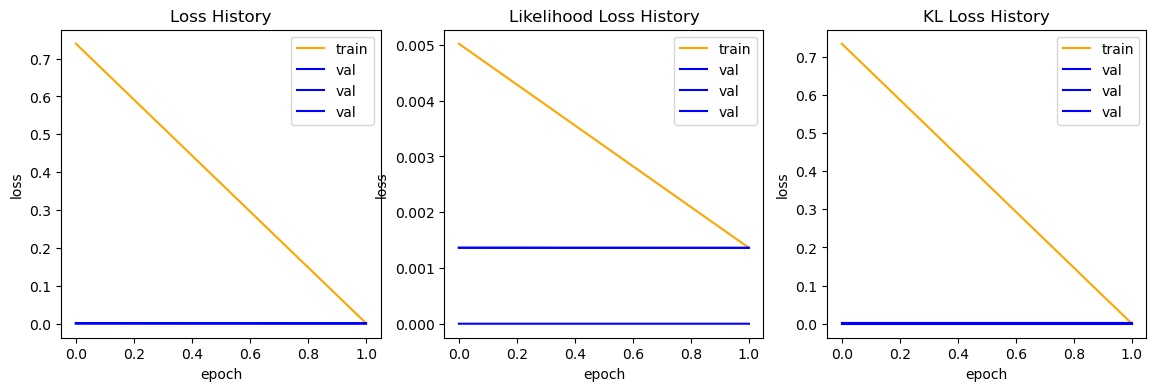

In [8]:
utils.show_training_history(euclidean_history)

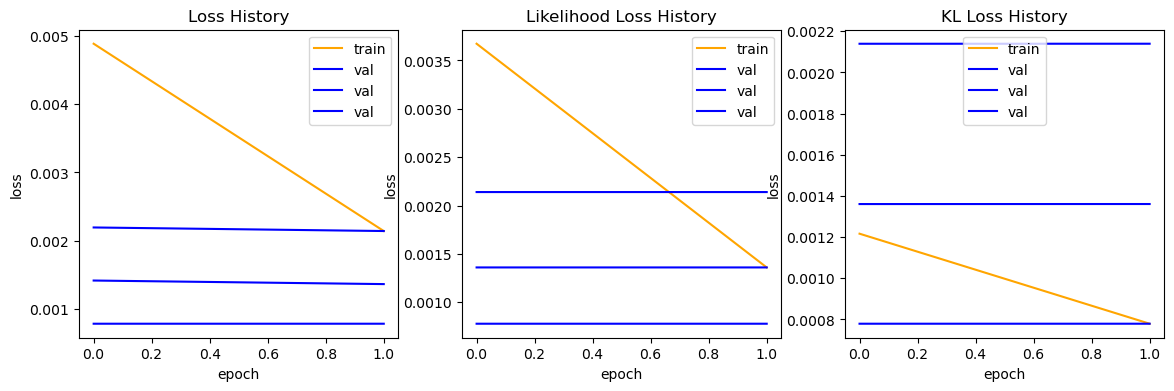

In [9]:
utils.show_training_history(toroidal_history)

### Save trained models

In [10]:
modelutils.save_model(euclidean_model, model_config)
modelutils.save_model(toroidal_model, model_config)

Model saved as gaussian_1739301106.pth
Model saved as gaussian_1739301106.json
Model saved as toroidal_1739301106.pth
Model saved as toroidal_1739301106.json


### Load pretrained models

In [11]:
#model = modelutils.load_model("gaussian_1738932113")

In [12]:
#model